In [21]:
import pandas as pd

# Load the dataset (make sure full.xlsx is in the same folder as this script)
df = pd.read_excel("full.xlsx")

print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()


✅ Dataset Loaded Successfully!
Shape: (4765, 8)


,mission_id,company,country,mission_name,launch_date,launch_vehicle,launch_status,price
0,1,Isro,India,Nike-Apache,1963-11-21,Nike-Apache,Success,56.5
1,2,Isro,India,Aryabhata,1975-04-19,Kosmos-3M,Success,56.5
2,3,Isro,India,Bhaskara-I,1979-06-07,Kosmos-3M,Success,56.5
3,4,Isro,India,Rohini-1,1980-07-18,Slv-3,Success,56.5
4,5,Isro,India,Apple,1981-06-19,Ariane-1,Success,56.5


In [22]:
# Clean and standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Column names standardized!")
print(df.columns.tolist())


✅ Column names standardized!
['mission_id', 'company', 'country', 'mission_name', 'launch_date', 'launch_vehicle', 'launch_status', 'price']


In [23]:
# Convert all string cells to consistent format (Title Case)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.lower().str.title()

print("✅ Text values standardized (India, Usa, etc.)")


✅ Text values standardized (India, Usa, etc.)


In [24]:
# Fill missing values with 'Unknown'
df.fillna('Unknown', inplace=True)

print("✅ Missing values handled!")
print(df.isnull().sum())


✅ Missing values handled!
mission_id        0
company           0
country           0
mission_name      0
launch_date       0
launch_vehicle    0
launch_status     0
price             0
dtype: int64


In [25]:
# Save back to the same Excel file (overwrite)
df.to_excel("full.xlsx", index=False)

print("🎉 Dataset cleaned and saved back to 'full.xlsx' successfully!")


🎉 Dataset cleaned and saved back to 'full.xlsx' successfully!


In [26]:
import pandas as pd

# Load the existing Excel file
df = pd.read_excel("full.xlsx")

# Clean and convert the 'price' column
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)  # Keep only digits and dots
    .replace("", None)                        # Empty strings → NaN
)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Fill missing values with the median
df["price"] = df["price"].fillna(df["price"].median())

# Save cleaned data back into the same Excel file
df.to_excel("full.xlsx", index=False)

print("✅ Price column cleaned, missing values filled, and saved in 'full.xlsx' successfully!")


✅ Price column cleaned, missing values filled, and saved in 'full.xlsx' successfully!


In [27]:
# Reload and preview
verify = pd.read_excel("full.xlsx")
verify.head()


,mission_id,company,country,mission_name,launch_date,launch_vehicle,launch_status,price
0,1,Isro,India,Nike-Apache,1963-11-21,Nike-Apache,Success,56.5
1,2,Isro,India,Aryabhata,1975-04-19,Kosmos-3M,Success,56.5
2,3,Isro,India,Bhaskara-I,1979-06-07,Kosmos-3M,Success,56.5
3,4,Isro,India,Rohini-1,1980-07-18,Slv-3,Success,56.5
4,5,Isro,India,Apple,1981-06-19,Ariane-1,Success,56.5


In [28]:
import os
os.makedirs("outputs", exist_ok=True)


In [1]:
# PREP: imports, paths, safe column detection, create outputs folder
import os, math
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib, warnings
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

# Load cleaned dataset (full.xlsx). Adjust path if needed.
df = pd.read_excel("full.xlsx")

# Normalize columns to canonical names for this notebook
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Detect common column names
country_col = next((c for c in df.columns if "country" in c), "country")
company_col = next((c for c in df.columns if c in ["company","operator","agency"]), None)
vehicle_col = next((c for c in df.columns if "vehicle" in c or "rocket" in c), None)
date_col = next((c for c in df.columns if "date" in c), None)
status_col = next((c for c in df.columns if any(k in c for k in ["status","outcome","result"])), None)
price_col = next((c for c in df.columns if "price" in c or "cost" in c or "price_usd" in c), None)

# Ensure date parsing
if date_col and not np.issubdtype(df[date_col].dtype, np.datetime64):
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Add helper columns
df['year'] = df[date_col].dt.year if date_col else np.nan
df['is_india'] = df[country_col].str.lower().str.contains("india", na=False)
df['is_isro'] = False
if company_col:
    df['is_isro'] = df[company_col].str.lower().str.contains("isro", na=False)
# standard binary success flag
if status_col:
    df['success_flag'] = df[status_col].astype(str).str.lower().str.contains("succ", na=False).astype(int)
else:
    df['success_flag'] = np.nan

print("Loaded df shape:", df.shape)
print("Detected columns -> country:", country_col, ", company:", company_col, ", vehicle:", vehicle_col, ", date:", date_col, ", status:", status_col, ", price:", price_col)


Loaded df shape: (4765, 12)
Detected columns -> country: country , company: company , vehicle: launch_vehicle , date: launch_date , status: launch_status , price: price


In [ ]:
# 1) Choropleth - world missions by country (India highlighted)
country_counts = df[country_col].fillna("Unknown").value_counts().reset_index()
country_counts.columns = ["country", "missions"]

country_counts['country'] = country_counts['country'].astype(str)

fig = px.choropleth(country_counts, locations="country", locationmode="country names",
                    color="missions", hover_name="country",
                    title="Worldwide Missions by Country (India highlighted)")

ind = country_counts[country_counts['country'].str.lower().str.contains("india")]
if not ind.empty:
    fig.add_scattergeo(locations=ind['country'],
                       locationmode='country names',
                       marker=dict(size=12, color='red'),
                       name='India (highlight)')
out_html = "outputs/choropleth_missions_by_country.html"
fig.write_html(out_html)
print("Saved interactive choropleth to", out_html)
fig.show()


print("""
Insight: This choropleth visualizes total recorded space missions per country across the dataset.
India appears as a mid-to-high contributor depending on the dataset's coverage; the red marker explicitly highlights India/ISRO.
Choropleths let you quickly compare geographic participation: bright/darker countries are global leaders (US, Russia, China), 
while India’s relative color and marker show its regional prominence and growth compared to other countries.
""")


Saved interactive choropleth to outputs/choropleth_missions_by_country.html



Insight: This choropleth visualizes total recorded space missions per country across the dataset.
India appears as a mid-to-high contributor depending on the dataset's coverage; the red marker explicitly highlights India/ISRO.
Choropleths let you quickly compare geographic participation: bright/darker countries are global leaders (US, Russia, China), 
while India’s relative color and marker show its regional prominence and growth compared to other countries.



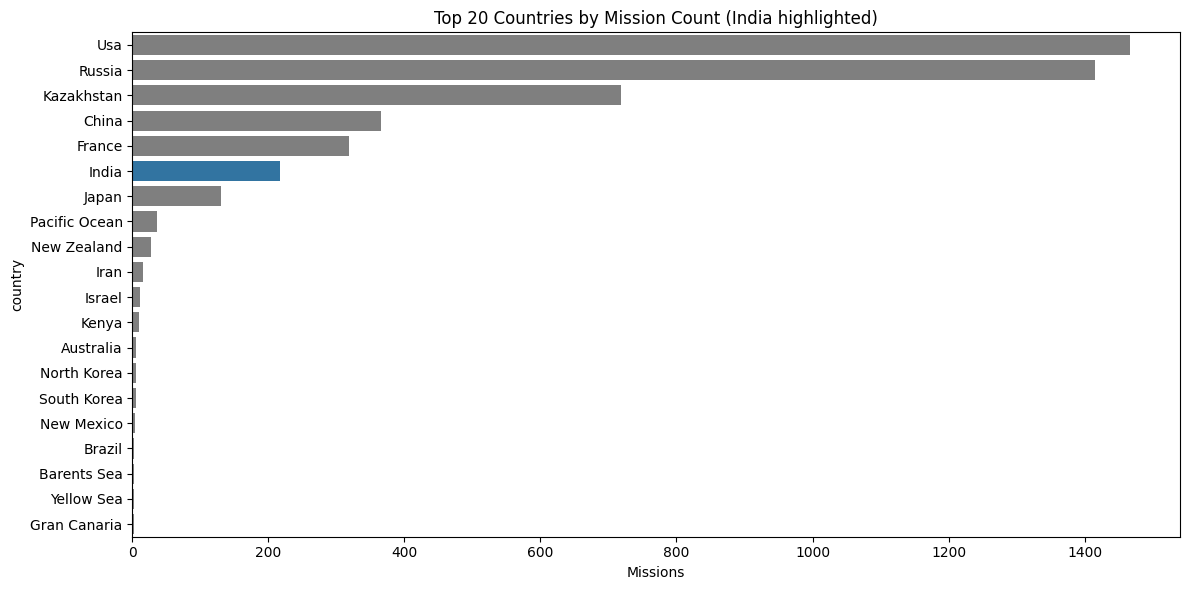

Saved: outputs/bar_top_countries.png

Insight: The horizontal bar chart ranks countries by mission count; India is emphasized in blue.
This view makes it easy to see where India stands versus top spacefaring nations.
Bar charts focus on absolute counts and reveal whether India is near the top tier or in a second tier of activity.



In [5]:
# 2) Bar chart - top countries with India highlighted
top_countries = df[country_col].fillna("Unknown").value_counts().head(20)
plt.figure(figsize=(12,6))
colors = ['tab:gray' if not ('india' in str(x).lower()) else 'tab:blue' for x in top_countries.index]
sns.barplot(x=top_countries.values, y=top_countries.index, palette=colors)
plt.title("Top 20 Countries by Mission Count (India highlighted)")
plt.xlabel("Missions")
plt.tight_layout()
plt.show()

out_png = "outputs/bar_top_countries.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
print("Saved:", out_png)
plt.show()

print("""
Insight: The horizontal bar chart ranks countries by mission count; India is emphasized in blue.
This view makes it easy to see where India stands versus top spacefaring nations.
Bar charts focus on absolute counts and reveal whether India is near the top tier or in a second tier of activity.
""")


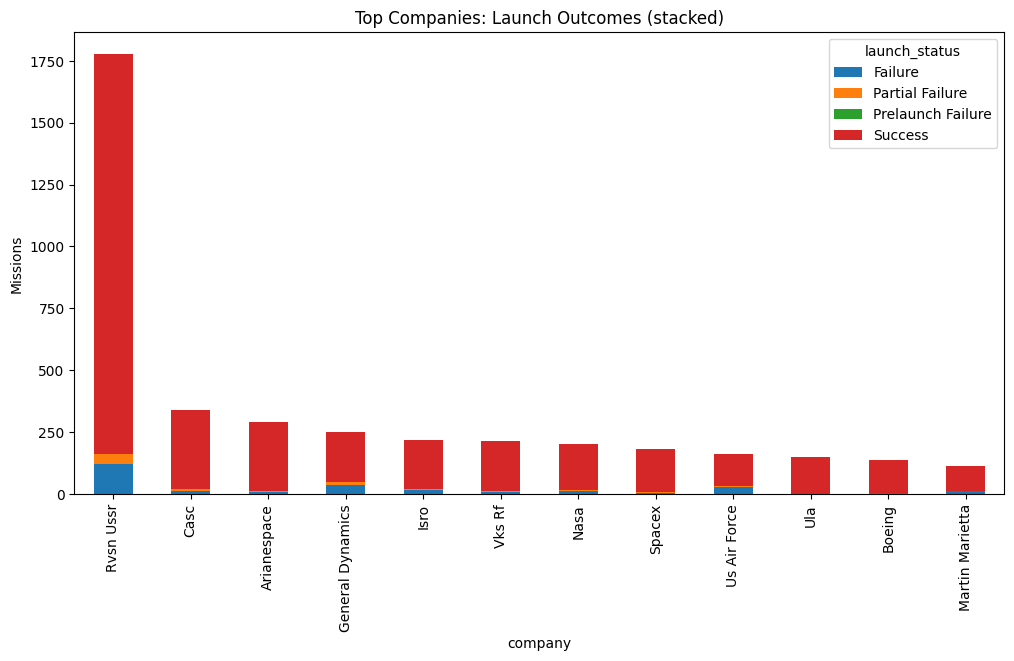

Saved: outputs/stacked_companies_outcomes.png

Insight: Stacked bars display how each major company’s missions break down by outcome (success/failure).
Comparing heights of 'success' segments across companies highlights relative reliability.
India/ISRO (if present among top companies) shows how its reliability compares to other organizations.



In [6]:
# 3) Stacked bar - top companies and success/failure distribution
if company_col and status_col:
    top_companies = df[company_col].fillna("Unknown").value_counts().head(12).index
    temp = df[df[company_col].isin(top_companies)].copy()
    pivot = pd.crosstab(temp[company_col], temp[status_col].fillna("unknown"))
    pivot = pivot.loc[top_companies]  # keep same order
    pivot.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title("Top Companies: Launch Outcomes (stacked)")
    plt.ylabel("Missions")
    plt.show()

    out_png = "outputs/stacked_companies_outcomes.png"
    plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
    print("Saved:", out_png)

    print("""
Insight: Stacked bars display how each major company’s missions break down by outcome (success/failure).
Comparing heights of 'success' segments across companies highlights relative reliability.
India/ISRO (if present among top companies) shows how its reliability compares to other organizations.
""")
else:
    print("Skipping stacked company outcome plot (company or status columns missing).")


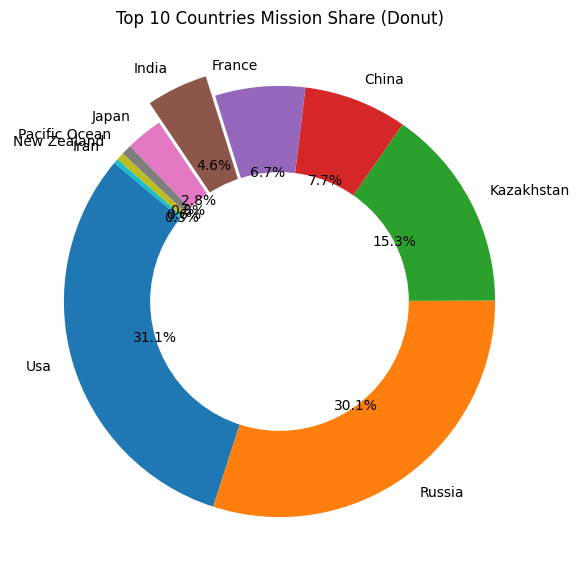

Saved: outputs/donut_country_share.png

Insight: The donut chart emphasizes share-of-total missions among the top countries. India’s exploded slice draws attention to its proportion.
Pie/donut charts are visually intuitive for dominance or share, but limit precise comparison; use alongside bar charts for exact counts.



In [7]:
# 4) Donut chart - global share with India slice emphasized
shares = df[country_col].fillna("Unknown").value_counts().head(10)
labels = shares.index.tolist()
vals = shares.values
# Explode India slice if present
explode = [0.1 if 'india' in str(l).lower() else 0 for l in labels]
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(vals, labels=labels, autopct="%1.1f%%", startangle=140, explode=explode)
# draw circle for donut
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig.gca().add_artist(centre_circle)
plt.title("Top 10 Countries Mission Share (Donut)")
plt.show()

out_png = "outputs/donut_country_share.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
print("Saved:", out_png)

print("""
Insight: The donut chart emphasizes share-of-total missions among the top countries. India’s exploded slice draws attention to its proportion.
Pie/donut charts are visually intuitive for dominance or share, but limit precise comparison; use alongside bar charts for exact counts.
""")


In [8]:
# 5) Bubble chart - mission count vs success rate per country, bubble by median price (if price exists)
group = df.groupby(country_col).agg(
    missions = (country_col, 'count'),
    success_rate = ('success_flag', 'mean'),
)
if price_col:
    group['median_price'] = df.groupby(country_col)[price_col].median().fillna(0)
else:
    group['median_price'] = group['missions']  # fallback sizing

group = group.dropna(subset=['success_rate']).reset_index()
# emphasize India
group['is_india'] = group[country_col].str.lower().str.contains('india')

fig = px.scatter(group, x='missions', y='success_rate', size='median_price', hover_name=country_col,
                 color='is_india', title='Missions vs Success Rate (bubble size = median price)')
fig.show()

out_html = "outputs/bubble_missions_vs_success.html"
fig.write_html(out_html)
print("Saved interactive bubble chart:", out_html)

print("""
Insight: This bubble visualization shows whether countries with many missions also maintain high success rates.
Larger bubbles indicate higher median costs (if available) — allowing economic/operational trade-offs to be seen.
India’s marker stands out via color, enabling quick visual comparison in count-success-cost space.
""")


Saved interactive bubble chart: outputs/bubble_missions_vs_success.html

Insight: This bubble visualization shows whether countries with many missions also maintain high success rates.
Larger bubbles indicate higher median costs (if available) — allowing economic/operational trade-offs to be seen.
India’s marker stands out via color, enabling quick visual comparison in count-success-cost space.



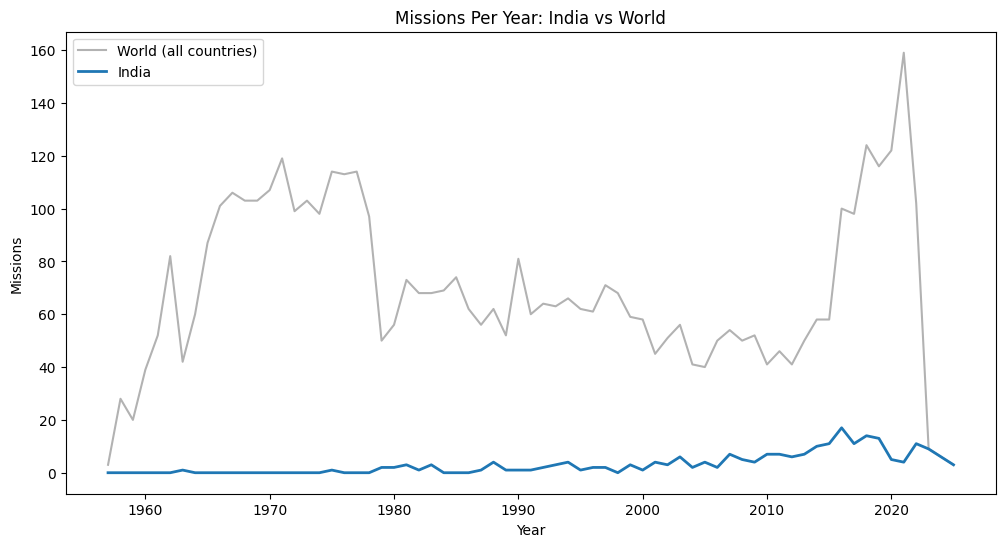

Saved: outputs/line_india_vs_world.png

Insight: Line chart compares temporal growth between India and world totals. It reveals whether India’s launch program grew in step with global trends or diverged.
Sharp increases show program expansion phases; plateaus or dips might signal programmatic slowdowns or data gaps.



In [9]:
# 6) Line chart - missions per year India vs Rest of World
df['year'] = df[date_col].dt.year
by_year = df.groupby(['year', df[country_col].str.lower().str.contains('india')])['mission_id'].count().reset_index()
by_year.columns = ['year','is_india','count']
pivot = by_year.pivot(index='year', columns='is_india', values='count').fillna(0)
pivot.columns = ['other','india'] if False else ['False','True']  # labels may be booleans
# Make into numeric series safely
india_series = pivot.iloc[:, -1] if pivot.shape[1]>1 else pivot.iloc[:,0]
world_series = df.groupby('year')['mission_id'].count()
plt.figure(figsize=(12,6))
plt.plot(world_series.index, world_series.values, label='World (all countries)', color='gray', alpha=0.6)
if 'True' in pivot.columns or pivot.shape[1]>1:
    plt.plot(india_series.index, india_series.values, label='India', color='tab:blue', linewidth=2)
plt.title("Missions Per Year: India vs World")
plt.xlabel("Year"); plt.ylabel("Missions"); plt.legend()
plt.show()

out_png = "outputs/line_india_vs_world.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
print("Saved:", out_png)

print("""
Insight: Line chart compares temporal growth between India and world totals. It reveals whether India’s launch program grew in step with global trends or diverged.
Sharp increases show program expansion phases; plateaus or dips might signal programmatic slowdowns or data gaps.
""")


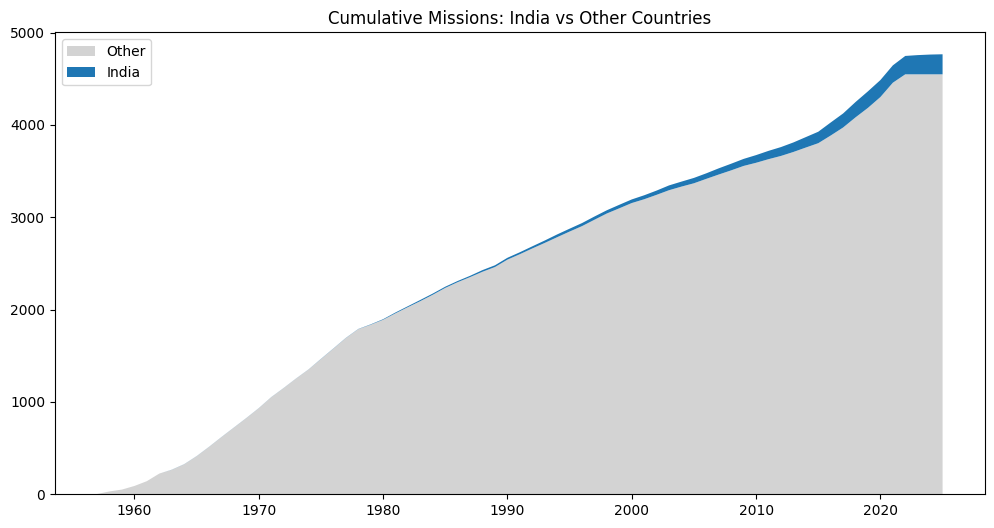

Saved: outputs/area_cumulative_missions.png

Insight: Cumulative area charts highlight long-term gradients: how much of cumulative global missions India represents over time.
A steep India area indicates rash program growth; comparatively steady other area suggests long-term global accumulation.



In [10]:
# 7) Area chart - cumulative missions
yearly = df.groupby(['year', df[country_col].str.lower().str.contains('india')])['mission_id'].count().reset_index()
yearly.columns = ['year','is_india','count']
yearly = yearly.pivot(index='year', columns='is_india', values='count').fillna(0)
if yearly.shape[1] == 1:
    yearly['other'] = yearly.iloc[:,0]
    yearly['india'] = 0
yearly_cum = yearly.cumsum()
plt.figure(figsize=(12,6))
plt.stackplot(yearly_cum.index, yearly_cum.iloc[:,0], yearly_cum.iloc[:,1], labels=['Other','India'], colors=['#d3d3d3','#1f77b4'])
plt.legend(loc='upper left')
plt.title("Cumulative Missions: India vs Other Countries")
plt.show()


out_png = "outputs/area_cumulative_missions.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
print("Saved:", out_png)

print("""
Insight: Cumulative area charts highlight long-term gradients: how much of cumulative global missions India represents over time.
A steep India area indicates rash program growth; comparatively steady other area suggests long-term global accumulation.
""")


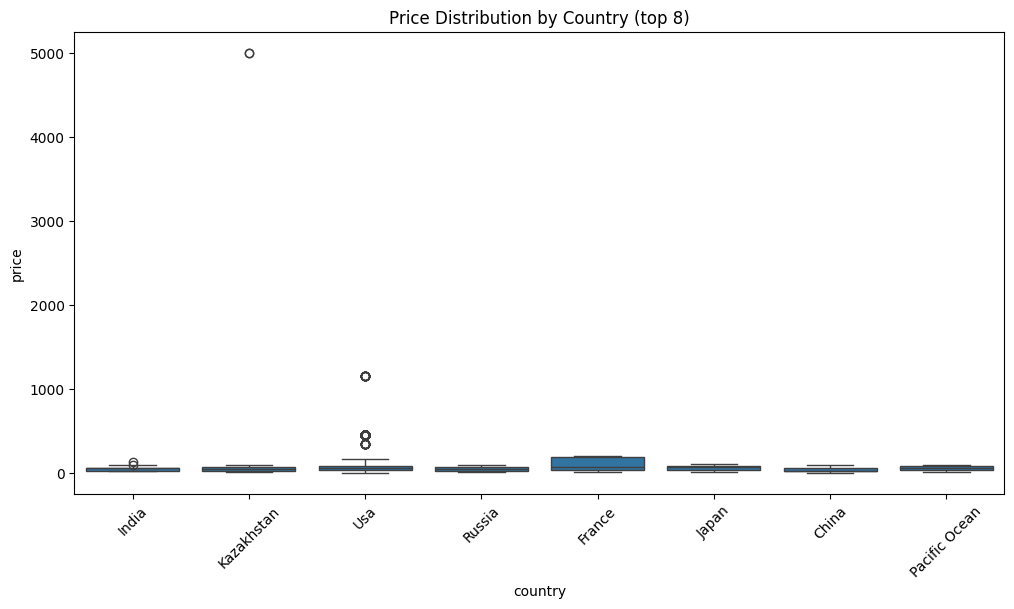

Saved: outputs/box_price_by_country.png

Insight: Box plots show cost dispersion per country; India’s box reveals median and spread of launch costs (if present).
Wide whiskers or outliers indicate occasional very expensive missions; tight boxes indicate cost consistency.



In [11]:
# 8) Boxplot - price distribution for top N countries
if price_col:
    topN = df[country_col].value_counts().head(8).index
    subset = df[df[country_col].isin(topN)]
    plt.figure(figsize=(12,6))
    sns.boxplot(x=country_col, y=price_col, data=subset)
    plt.xticks(rotation=45)
    plt.title("Price Distribution by Country (top 8)")
    plt.show()

    out_png = "outputs/box_price_by_country.png"
    plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
    print("Saved:", out_png)
    print("""
Insight: Box plots show cost dispersion per country; India’s box reveals median and spread of launch costs (if present).
Wide whiskers or outliers indicate occasional very expensive missions; tight boxes indicate cost consistency.
""")
else:
    print("Skipping price boxplot (no price column detected).")


In [13]:
# 9) Treemap - hierarchical country -> company -> mission counts
if company_col:
    treedf = df.groupby([country_col, company_col]).size().reset_index(name='missions')
    fig = px.treemap(treedf, path=[country_col, company_col], values='missions', title='Treemap: Country > Company > Missions')
    fig.show()

    out_html = "outputs/treemap_country_company.html"
    fig.write_html(out_html)
    print("Saved interactive treemap:", out_html)

    print("""
Insight: The treemap compresses hierarchical info: larger country blocks mean more missions; within each, companies are sized by mission share.
India’s block (and ISRO rectangle inside it) shows domestic concentration compared to other countries’ multi-company ecosystems.
""")
else:
    print("Skipping treemap (company column missing).")


Saved interactive treemap: outputs/treemap_country_company.html

Insight: The treemap compresses hierarchical info: larger country blocks mean more missions; within each, companies are sized by mission share.
India’s block (and ISRO rectangle inside it) shows domestic concentration compared to other countries’ multi-company ecosystems.



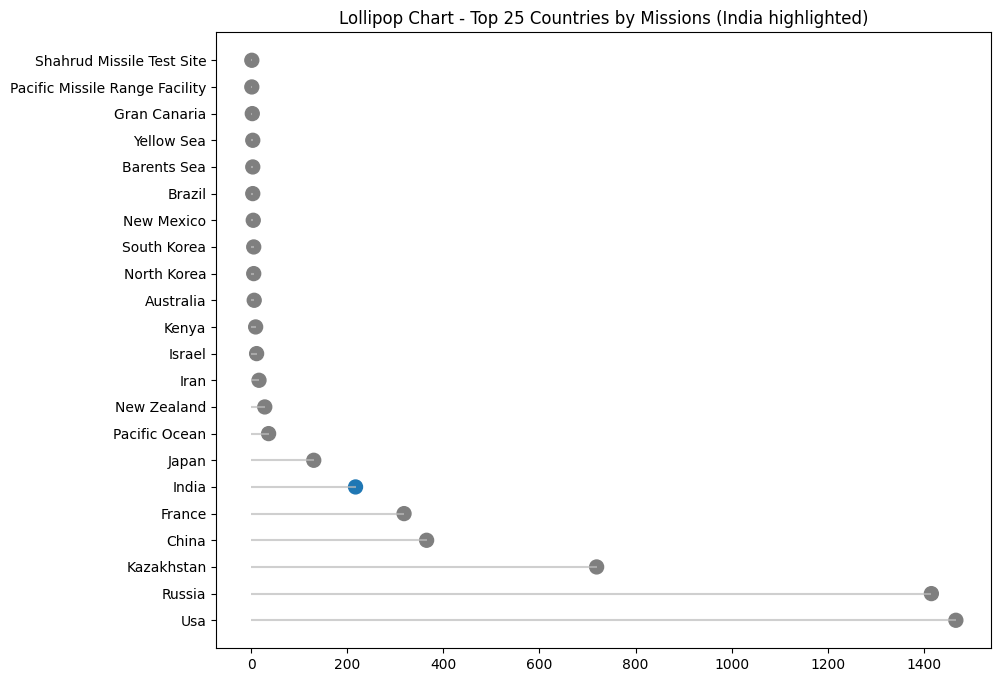

Saved: outputs/lollipop_top25.png

Insight: Lollipop charts combine ranking clarity with clean aesthetics; India’s marker is highlighted, showing direct rank position among top countries.
They are useful for quick rank-readability compared to dense bar charts.



In [16]:
# 11) Lollipop chart - ranking countries but highlight India
ranked = df[country_col].value_counts().reset_index()
ranked.columns = ['country','count']
ranked = ranked.head(25)
plt.figure(figsize=(10,8))
plt.hlines(y=ranked['country'], xmin=0, xmax=ranked['count'], color='#bbbbbb', alpha=0.7)
plt.scatter(ranked['count'], ranked['country'], color=['tab:blue' if 'india' in str(c).lower() else 'tab:gray' for c in ranked['country']], s=100)
plt.title("Lollipop Chart - Top 25 Countries by Missions (India highlighted)")
plt.show()

out_png = "outputs/lollipop_top25.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.close()
print("Saved:", out_png)

print("""
Insight: Lollipop charts combine ranking clarity with clean aesthetics; India’s marker is highlighted, showing direct rank position among top countries.
They are useful for quick rank-readability compared to dense bar charts.
""")


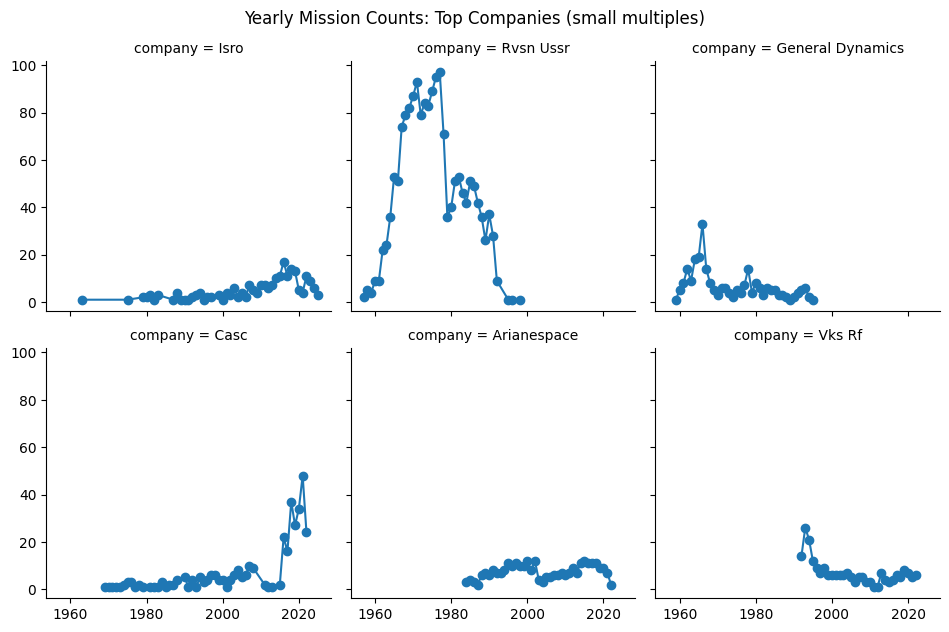

Saved: outputs/smallmultiples_top_companies.png

Insight: Small multiples let you compare temporal patterns across companies at equal scale — see which companies ramped up and when.
India/ISRO (if among top companies) is easy to compare alongside private and government organizations.



In [17]:
# 12) Small multiples: yearly missions for top companies (facet grid)
if company_col and date_col:
    top_comp = df[company_col].value_counts().head(6).index
    small = df[df[company_col].isin(top_comp)].copy()
    small['year'] = df[date_col].dt.year
    g = sns.FacetGrid(small, col=company_col, col_wrap=3, height=3.2, sharey=True)
    g.map_dataframe(lambda data, color: plt.plot(data.groupby('year').size().index, data.groupby('year').size().values, marker='o'))
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("Yearly Mission Counts: Top Companies (small multiples)")
    plt.show()

    out_png = "outputs/smallmultiples_top_companies.png"
    g.savefig(out_png, bbox_inches='tight', dpi=150); plt.close()
    print("Saved:", out_png)
    print("""
Insight: Small multiples let you compare temporal patterns across companies at equal scale — see which companies ramped up and when.
India/ISRO (if among top companies) is easy to compare alongside private and government organizations.
""")
else:
    print("Skipping small multiples (company or date column missing).")


ML data shape (with success_flag): (4765, 12)
XGBoost trained.
--- LogisticRegression ---
Accuracy: 0.9003147953830011
ROC-AUC: 0.6808060360691939
Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        95
           1       0.90      1.00      0.95       858

    accuracy                           0.90       953
   macro avg       0.45      0.50      0.47       953
weighted avg       0.81      0.90      0.85       953


--- RandomForest ---
Accuracy: 0.8940188877229801
ROC-AUC: 0.7470862470862472
Classification report:
               precision    recall  f1-score   support

           0       0.43      0.19      0.26        95
           1       0.92      0.97      0.94       858

    accuracy                           0.89       953
   macro avg       0.67      0.58      0.60       953
weighted avg       0.87      0.89      0.88       953


--- GradientBoosting ---
Accuracy: 0.8982161594963274
ROC-AUC: 0.740682

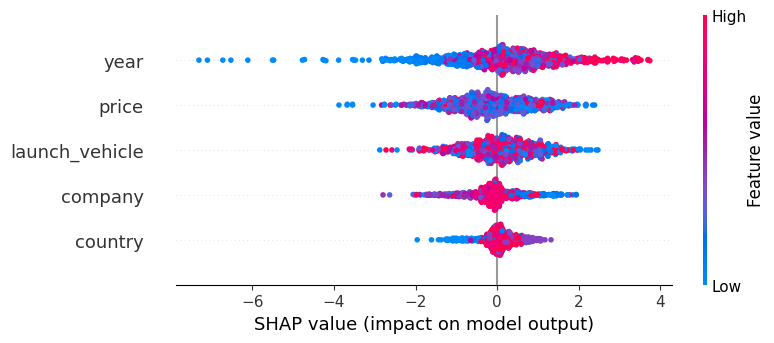

Saved SHAP summary plots for XGBoost


In [20]:
# ML: Predict Success (classification) with multiple models and SHAP
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import joblib

# Prepare dataset: drop rows missing status
data = df.dropna(subset=['success_flag']).copy()
print("ML data shape (with success_flag):", data.shape)

# Choose features - year, vehicle, company, country, price (if exists)
features = []
if 'year' in data.columns: features.append('year')
if vehicle_col: features.append(vehicle_col)
if company_col: features.append(company_col)
if country_col: features.append(country_col)
if price_col: features.append(price_col)

X = data[features].copy()
y = data['success_flag'].astype(int)

# Encode categorical features
encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Fill numeric NaNs if any
X = X.fillna(X.median())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {}
results = {}

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
results['LogisticRegression'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
    'report': classification_report(y_test, y_pred, output_dict=False)
}
models['LogisticRegression'] = lr

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results['RandomForest'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
    'report': classification_report(y_test, y_pred, output_dict=False)
}
models['RandomForest'] = rf

# Model 3: Gradient Boosting (sklearn)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results['GradientBoosting'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]),
    'report': classification_report(y_test, y_pred, output_dict=False)
}
models['GradientBoosting'] = gb

# Model 4: XGBoost (if available)
try:
    import xgboost as xgb
    xg = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
    xg.fit(X_train, y_train)
    y_pred = xg.predict(X_test)
    results['XGBoost'] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, xg.predict_proba(X_test)[:,1]),
        'report': classification_report(y_test, y_pred, output_dict=False)
    }
    models['XGBoost'] = xg
    print("XGBoost trained.")
except Exception as e:
    print("XGBoost not available or failed:", e)

# Print results summary
for name, res in results.items():
    print(f"--- {name} ---")
    print("Accuracy:", res['accuracy'])
    print("ROC-AUC:", res['roc_auc'])
    print("Classification report:\n", res['report'])
    print()

# Save best model (by roc_auc)
best_name = max(results.items(), key=lambda kv: kv[1]['roc_auc'])[0]
best_model = models[best_name]
joblib.dump(best_model, f"outputs/best_model_{best_name}.joblib")
joblib.dump(encoders, "outputs/label_encoders.joblib")
print("Saved best model:", best_name)

# SHAP explanations for tree models (RandomForest/GB/XGBoost)
try:
    import shap
    shap.initjs()
    tree_model = None
    for mname in ['XGBoost','RandomForest','GradientBoosting']:
        if mname in models:
            tree_model = models[mname]; model_name_for_shap = mname; break
    if tree_model is not None:
        explainer = shap.Explainer(tree_model, X_train)
        sv = explainer(X_test)
        # SHAP summary plot (bar)
        shap.plots.bar(sv, show=False)
        plt.savefig("outputs/shap_summary_bar.png", bbox_inches='tight', dpi=150); plt.close()
        # SHAP summary dot plot
        shap.plots.beeswarm(sv, show=False)
        plt.show()
        plt.savefig("outputs/shap_summary_beeswarm.png", bbox_inches='tight', dpi=150); plt.close()
        print("Saved SHAP summary plots for", model_name_for_shap)
        plt.show()

    else:
        print("No tree-based model available for SHAP.")
except Exception as e:
    print("SHAP failed or not installed:", e)
